In [1]:
from datetime import datetime
import pandas as pd

# Pipeline optimizado para portafolio de GitHub (Enfoque analítico / Data Analyst)
data = {
    'fecha': [
        datetime(2026, 9, 1),
        datetime(2026, 9, 1),
        datetime(2026, 9, 1),
        datetime(2026, 9, 1),
        datetime(2026, 9, 1),
        datetime(2026, 9, 1),
        datetime(2026, 9, 1),
        datetime(2026, 9, 1),
        datetime(2026, 9, 1)
    ],
    'tipo': [
        'Ingreso',
        'Ingreso',
        'Ingreso',
        'Egreso',
        'Egreso',
        'Egreso',
        'Egreso',
        'Egreso',
        'Egreso'
    ],
    'categoria': [
        'Salario',
        'Salario',
        'Salario',
        'Alimentación',
        'Transporte',
        'Servicios',
        'Telefonia e internet',
        'Federal seguros',
        'Gastos personales'
    ],
    'subcategoria': [
        'Hospital Luján',
        'Hospital San José',
        'Domicilio',
        'Supermercado',
        'Combustible',
        'Luz',
        'Movistar',
        'Seguro moto y Malapraxis',
        'Psicologa'
    ],
    'monto': [1221413, 1043645, 512160, 774242, 88000, 135000, 11000, 30000, 200000],
    'moneda': ['ARS', 'ARS', 'ARS', 'ARS', 'ARS', 'ARS', 'ARS', 'ARS', 'ARS'],
    'metodo_pago': ['Transferencia', 'Transferencia', 'Tansferencia', 'Debito automatico', 'Débito Automático', 'Debito automatico', 'Debito automatico', 'Debito automatico', 'Transferencia'],
    'observaciones': ['Sueldo Luján', 'Sueldo San José', 'Domicilio Rafa', 'Compra mensual', 'Nafta', 'CESPLL', 'Movistar', 'Melo Seguros', 'Gloria Ruiz']
}

# Construcción y ordenamiento cronológico estándar para visualización limpia en repositorio
df_finanzas = pd.DataFrame(data)
df_finanzas['fecha'] = pd.to_datetime(df_finanzas['fecha'])
df_finanzas = df_finanzas.sort_values('fecha').reset_index(drop=True)

# Exportación directa optimizada para control de versiones
df_finanzas.to_csv('finanzas_personales.csv', index=False, encoding='utf-8')

In [2]:
df_finanzas.head()

,fecha,tipo,categoria,subcategoria,monto,moneda,metodo_pago,observaciones
0,2026-09-01,Ingreso,Salario,Hospital Luján,1221413,ARS,Transferencia,Sueldo Luján
1,2026-09-01,Ingreso,Salario,Hospital San José,1043645,ARS,Transferencia,Sueldo San José
2,2026-09-01,Ingreso,Salario,Domicilio,512160,ARS,Tansferencia,Domicilio Rafa
3,2026-09-01,Egreso,Alimentación,Supermercado,774242,ARS,Debito automatico,Compra mensual
4,2026-09-01,Egreso,Transporte,Combustible,88000,ARS,Débito Automático,Nafta


In [3]:
df_finanzas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   fecha          9 non-null      datetime64[ns]
 1   tipo           9 non-null      object        
 2   categoria      9 non-null      object        
 3   subcategoria   9 non-null      object        
 4   monto          9 non-null      int64         
 5   moneda         9 non-null      object        
 6   metodo_pago    9 non-null      object        
 7   observaciones  9 non-null      object        
dtypes: datetime64[ns](1), int64(1), object(6)
memory usage: 708.0+ bytes


In [4]:
df_finanzas.to_csv('finanzas_personales.csv', index=False, encoding='utf-8')

--- BALANCE GENERAL ---
tipo
Egreso     1238242
Ingreso    2777218
Name: monto, dtype: int64

Flujo de Caja Neto: $1,538,976.00
Fondo de Inversión Sugerido (15%): $416,582.70


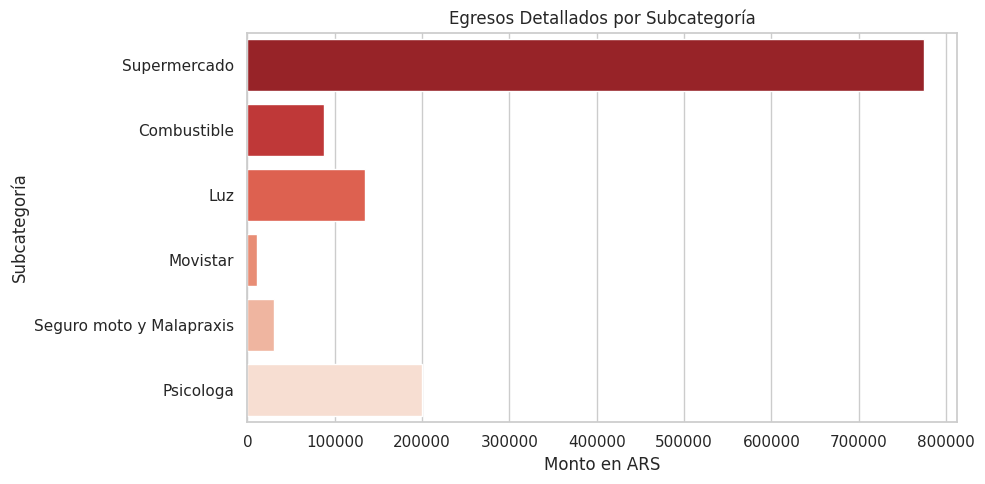

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Análisis de KPIs Financieros y Flujo de Caja
balance_general = df_finanzas.groupby('tipo')['monto'].sum()
total_ingresos = balance_general.get('Ingreso', 0)
total_egresos = balance_general.get('Egreso', 0)
flujo_neto = total_ingresos - total_egresos
ahorro_objetivo = total_ingresos * 0.15

print('--- BALANCE GENERAL ---')
print(balance_general)
print(f'\nFlujo de Caja Neto: ${flujo_neto:,.2f}')
print(f'Fondo de Inversión Sugerido (15%): ${ahorro_objetivo:,.2f}')

# 2. Visualización para el Portafolio (Gráfico de Egresos)
sns.set_theme(style='whitegrid')
plt.figure(figsize=(10, 5))
egresos = df_finanzas[df_finanzas['tipo'] == 'Egreso']
sns.barplot(
    data=egresos,
    x='monto',
    y='subcategoria',
    palette='Reds_r',
    hue='subcategoria',
    legend=False,
)
plt.title('Egresos Detallados por Subcategoría')
plt.xlabel('Monto en ARS')
plt.ylabel('Subcategoría')
plt.tight_layout()
plt.show()